# Random controls for predicted-mask retrieval

Predicted-ROI retrieval outputs from notebook 08c are compared with random neighbor controls using the same patient order and reference-feature schema.

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


In [2]:
from brats_pipeline.retrieval import BaselineContext
from brats_pipeline.common import save_dataframe as _save_dataframe, safe_display

In [3]:


import os
import json
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration

Inputs are read from notebook 08c, not notebook 08.

In [4]:


CFG = {
    "project_root": str(PROJECT_ROOT),

    # Source directory produced by 08c.
    "source_08c_dir": "docs/08c_predicted_mask_roi_embedding_retrieval_test",

    # Output directory for this analysis.
    "output_dir": "docs/08d_predicted_roi_random_and_domain_matched_baselines_test",

    "seed": 42,
    "n_random_repeats": 1000,
    "domain_specific_repeats": 500,
    "top_k": [1, 3, 5, 10],

    # Expected test cohort size; set None for smoke tests.
    "expected_n_cases": 211,

    "metric_cols": [
        "same_domain_rate",
        "cross_domain_rate",
        "same_ET_presence_rate",
        "mean_abs_log1p_WT_diff",
        "mean_abs_log1p_TC_diff",
        "mean_abs_log1p_ET_diff",
        "mean_tumor_feature_z_distance",
        "mean_WT_centroid_distance",
        "mean_TC_centroid_distance",
        "mean_ET_centroid_distance",
    ],

    # Primary analysis uses encoder embeddings.
    "primary_retrieval_space": "embedding",
    "primary_k": 5,

    # Other spaces are secondary ablations from 08c:
    # pred_tumor_features and hybrid_pred_features use predicted segmentation-derived features.
    "baseline_types": [
        "global_random",
        "same_domain_random_strict",
        "domain_distribution_matched_random",
    ],
}

PROJECT_ROOT = Path(CFG["project_root"]).expanduser().resolve()
OUT_DIR = (PROJECT_ROOT / CFG["output_dir"]).resolve()
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
REPORT_DIR = OUT_DIR / "reports"
LOG_DIR = OUT_DIR / "logs"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(CFG["seed"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SOURCE_08C_DIR:", CFG["source_08c_dir"])
print("OUT_DIR:", OUT_DIR)
print("n_random_repeats:", CFG["n_random_repeats"])
print("top_k:", CFG["top_k"])
print("primary:", CFG["primary_retrieval_space"], "@k=", CFG["primary_k"])

PROJECT_ROOT: /home/mandrakedrink/projects/research_ts_bs
SOURCE_08C_DIR: docs/08c_predicted_mask_roi_embedding_retrieval_test
OUT_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test
n_random_repeats: 1000
top_k: [1, 3, 5, 10]
primary: embedding @k= 5


In [5]:
save_dataframe = partial(_save_dataframe, table_dir=TABLE_DIR)




def resolve_08c_artifact(relative_path, required=True):
    return resolve_existing_path(
        Path(CFG["source_08c_dir"]) / relative_path,
        required=required,
        label=f"08c artifact {relative_path}",
    )

## Load notebook 08c artifacts

In [9]:


paths = {
    "eval_patient_list": resolve_08c_artifact("tables/01_eval_patient_list.csv"),
    "features": resolve_08c_artifact("tables/03_gt_tumor_phenotype_features.csv"),
    "neighbors": resolve_08c_artifact("tables/09_pred_roi_topk_neighbors_long.csv"),
    "query_metrics": resolve_08c_artifact("tables/10_pred_roi_query_level_retrieval_metrics.csv"),
    "overall_metrics": resolve_08c_artifact("tables/11_pred_roi_overall_retrieval_metrics.csv"),
    "domain_metrics": resolve_08c_artifact("tables/12_pred_roi_domain_stratified_retrieval_metrics.csv"),
    "center_diagnostics_overall": resolve_08c_artifact("tables/13_pred_roi_center_diagnostics_overall.csv"),
    "center_diagnostics_by_domain": resolve_08c_artifact("tables/14_pred_roi_center_diagnostics_by_domain.csv"),
    "source_08c_checks": resolve_08c_artifact("tables/19_output_checks.csv"),
    "tumor_feature_z": resolve_08c_artifact("embeddings/tumor_feature_z.npy"),
    "tumor_feature_raw_features": resolve_08c_artifact("embeddings/tumor_feature_raw_features.csv"),
}

optional_paths = {
    "pred_roi_vs_gt_roi_comparison": resolve_08c_artifact(
        "tables/15_pred_roi_vs_gt_roi_overall_comparison.csv",
        required=False
    ),
    "paper_pred_roi_embedding_k5_summary": resolve_08c_artifact(
        "tables/17_paper_pred_roi_embedding_k5_summary.csv",
        required=False
    ),
}

artifact_df = pd.DataFrame([
    {"artifact": k, "path": str(v), "exists": v.exists() if v is not None else False, "required": True}
    for k, v in paths.items()
] + [
    {
        "artifact": k,
        "path": str(v) if v is not None else None,
        "exists": v.exists() if v is not None else False,
        "required": False
    }
    for k, v in optional_paths.items()
])

safe_display("Resolved 08c artifacts", artifact_df, n=30)
save_dataframe(artifact_df, "01_resolved_08c_artifacts")

eval_df = pd.read_csv(paths["eval_patient_list"])
features_df = pd.read_csv(paths["features"])
neighbors_df = pd.read_csv(paths["neighbors"])
query_metrics_df = pd.read_csv(paths["query_metrics"])
overall_metrics_df = pd.read_csv(paths["overall_metrics"])
domain_metrics_df = pd.read_csv(paths["domain_metrics"])
center_overall_df = pd.read_csv(paths["center_diagnostics_overall"])
center_domain_df = pd.read_csv(paths["center_diagnostics_by_domain"])
source_checks_df = pd.read_csv(paths["source_08c_checks"])

tumor_feature_z = np.load(paths["tumor_feature_z"])
tumor_feature_raw_df = pd.read_csv(paths["tumor_feature_raw_features"])

roi_comparison_df = pd.read_csv(optional_paths["pred_roi_vs_gt_roi_comparison"]) if optional_paths["pred_roi_vs_gt_roi_comparison"] is not None else None
paper_summary_df = pd.read_csv(optional_paths["paper_pred_roi_embedding_k5_summary"]) if optional_paths["paper_pred_roi_embedding_k5_summary"] is not None else None

print("eval_df:", eval_df.shape)
print("features_df:", features_df.shape)
print("neighbors_df:", neighbors_df.shape)
print("query_metrics_df:", query_metrics_df.shape)
print("overall_metrics_df:", overall_metrics_df.shape)
print("domain_metrics_df:", domain_metrics_df.shape)
print("center_overall_df:", center_overall_df.shape)
print("tumor_feature_z:", tumor_feature_z.shape)

### Resolved 08c artifacts

,artifact,path,exists,required
0,eval_patient_list,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
1,features,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
2,neighbors,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
3,query_metrics,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
4,overall_metrics,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
5,domain_metrics,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
6,center_diagnostics_overall,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
7,center_diagnostics_by_domain,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
8,source_08c_checks,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
9,tumor_feature_z,/home/mandrakedrink/projects/research_ts_bs/do...,True,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/01_resolved_08c_artifacts.csv
eval_df: (211, 3)
features_df: (211, 41)
neighbors_df: (18990, 29)
query_metrics_df: (7596, 18)
overall_metrics_df: (36, 16)
domain_metrics_df: (144, 14)
center_overall_df: (3, 10)
tumor_feature_z: (211, 34)


## Schema and integrity validation

In [10]:


required_eval_cols = {"patient_id", "client_domain", "split"}
required_feature_cols = {"patient_id", "log1p_WT_vox", "log1p_TC_vox", "log1p_ET_vox", "ET_present"}
required_neighbor_cols = {
    "experiment_key", "retrieval_space",
    "query_patient_id", "query_domain",
    "neighbor_rank", "neighbor_patient_id", "neighbor_domain",
}
required_overall_cols = {
    "experiment_key", "retrieval_space", "k",
    "same_domain_rate", "same_ET_presence_rate",
    "mean_abs_log1p_ET_diff", "mean_tumor_feature_z_distance",
}
required_center_cols = {"experiment_key", "n_cases", "n_no_pred_wt", "no_pred_wt_rate"}

checks = []


def check_cols(df, required, name):
    missing = sorted(required - set(df.columns))
    checks.append({
        "check": f"{name}_required_columns",
        "passed": len(missing) == 0,
        "details": ", ".join(missing)
    })
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")


check_cols(eval_df, required_eval_cols, "eval_df")
check_cols(features_df, required_feature_cols, "features_df")
check_cols(neighbors_df, required_neighbor_cols, "neighbors_df")
check_cols(overall_metrics_df, required_overall_cols, "overall_metrics_df")
check_cols(center_overall_df, required_center_cols, "center_overall_df")

eval_df["patient_id"] = eval_df["patient_id"].astype(str)
features_df["patient_id"] = features_df["patient_id"].astype(str)
tumor_feature_raw_df["patient_id"] = tumor_feature_raw_df["patient_id"].astype(str)

eval_ids = eval_df["patient_id"].tolist()
feature_ids = features_df["patient_id"].tolist()
raw_feature_ids = tumor_feature_raw_df["patient_id"].tolist()

split_values = sorted(eval_df["split"].astype(str).unique().tolist())
expected_n = CFG.get("expected_n_cases")

source_check_cols = set(source_checks_df.columns)


def first_bool(df, col, default=False):
    if col not in df.columns or len(df) == 0:
        return bool(default)
    v = df[col].iloc[0]
    if isinstance(v, (bool, np.bool_)):
        return bool(v)
    if pd.isna(v):
        return bool(default)
    return str(v).strip().lower() in {"true", "1", "yes", "y"}


source_08c_ready = first_bool(source_checks_df, "complete")
source_08c_no_gt_fallback = first_bool(source_checks_df, "gt_fallback_not_used")
source_08c_gt_fallback_disabled = first_bool(source_checks_df, "gt_fallback_disabled")

primary_space = CFG["primary_retrieval_space"]
primary_k = int(CFG["primary_k"])
primary_available = bool(
    ((overall_metrics_df["retrieval_space"].astype(str) == primary_space) &
     (overall_metrics_df["k"].astype(int) == primary_k)).any()
)

norms = np.linalg.norm(tumor_feature_z, axis=1)

checks.extend([
    {
        "check": "source_08c_complete",
        "passed": source_08c_ready,
        "details": f"columns={sorted(source_check_cols)}",
    },
    {
        "check": "source_08c_gt_fallback_disabled",
        "passed": source_08c_gt_fallback_disabled,
        "details": str(source_08c_gt_fallback_disabled),
    },
    {
        "check": "source_08c_gt_fallback_not_used",
        "passed": source_08c_no_gt_fallback,
        "details": str(source_08c_no_gt_fallback),
    },
    {
        "check": "split_is_test_only",
        "passed": split_values == ["test"],
        "details": str(split_values),
    },
    {
        "check": "expected_n_cases",
        "passed": True if expected_n is None else len(eval_df) == int(expected_n),
        "details": f"observed={len(eval_df)}, expected={expected_n}",
    },
    {
        "check": "features_patient_order_matches_eval",
        "passed": feature_ids == eval_ids,
        "details": f"features={len(feature_ids)}, eval={len(eval_ids)}",
    },
    {
        "check": "raw_feature_patient_order_matches_eval",
        "passed": raw_feature_ids == eval_ids,
        "details": f"raw_features={len(raw_feature_ids)}, eval={len(eval_ids)}",
    },
    {
        "check": "tumor_feature_z_shape_matches_eval",
        "passed": tumor_feature_z.shape[0] == len(eval_df),
        "details": str(tumor_feature_z.shape),
    },
    {
        "check": "tumor_feature_z_all_finite",
        "passed": bool(np.isfinite(tumor_feature_z).all()),
        "details": f"finite={bool(np.isfinite(tumor_feature_z).all())}",
    },
    {
        "check": "tumor_feature_z_l2_normalized",
        "passed": bool(np.allclose(norms, 1.0, atol=1e-4)),
        "details": f"mean_norm={float(norms.mean()):.6f}, min={float(norms.min()):.6f}, max={float(norms.max()):.6f}",
    },
    {
        "check": "primary_embedding_k5_available",
        "passed": primary_available,
        "details": f"space={primary_space}, k={primary_k}",
    },
    {
        "check": "no_pred_wt_fallback_in_08c",
        "passed": bool((pd.to_numeric(
            center_overall_df["n_no_pred_wt"],
            errors="coerce"
        ).fillna(999) == 0).all()),
        "details": center_overall_df[[
            "experiment_key",
            "n_no_pred_wt",
            "no_pred_wt_rate"
        ]].to_dict("records"),
    },
])

integrity_df = pd.DataFrame(checks)
safe_display("Integrity checks", integrity_df, n=50)
save_dataframe(integrity_df, "02_integrity_checks")

if not integrity_df["passed"].all():
    failed = integrity_df[~integrity_df["passed"]]
    display(failed)
    raise RuntimeError("08d integrity checks failed. Fix the source 08c artifacts before running random baselines.")

### Integrity checks

,check,passed,details
0,eval_df_required_columns,True,
1,features_df_required_columns,True,
2,neighbors_df_required_columns,True,
3,overall_metrics_df_required_columns,True,
4,center_overall_df_required_columns,True,
5,source_08c_complete,True,"columns=['complete', 'domain_metrics_available..."
6,source_08c_gt_fallback_disabled,True,True
7,source_08c_gt_fallback_not_used,True,True
8,split_is_test_only,True,['test']
9,expected_n_cases,True,"observed=211, expected=211"


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/02_integrity_checks.csv


In [11]:


patient_df = eval_df.copy()
patient_df["patient_id"] = patient_df["patient_id"].astype(str)
patient_df["client_domain"] = patient_df["client_domain"].astype(str)

features_df = features_df.copy()
features_df["patient_id"] = features_df["patient_id"].astype(str)
features_df = features_df.set_index("patient_id").loc[patient_df["patient_id"]].reset_index()

domain_arr = patient_df["client_domain"].to_numpy()
patient_ids = patient_df["patient_id"].to_numpy()
N = len(patient_df)

pid_to_idx = {pid: i for i, pid in enumerate(patient_ids)}
idx_to_pid = {i: pid for i, pid in enumerate(patient_ids)}

domain_counts = patient_df["client_domain"].value_counts().sort_index()
domain_counts_df = domain_counts.rename_axis("client_domain").reset_index(name="n")
safe_display("Domain counts", domain_counts_df, n=20)
save_dataframe(domain_counts_df, "03_domain_counts")

def arr_col(col, default=np.nan):
    if col in features_df.columns:
        return pd.to_numeric(features_df[col], errors="coerce").to_numpy()
    return np.full(N, default, dtype=float)

log1p_WT = arr_col("log1p_WT_vox")
log1p_TC = arr_col("log1p_TC_vox")
log1p_ET = arr_col("log1p_ET_vox")
ET_present = arr_col("ET_present", default=0).astype(float) > 0.5

centroid_cols = {
    "WT": ["WT_centroid_x", "WT_centroid_y", "WT_centroid_z"],
    "TC": ["TC_centroid_x", "TC_centroid_y", "TC_centroid_z"],
    "ET": ["ET_centroid_x", "ET_centroid_y", "ET_centroid_z"],
}

centroids = {}
for region, cols in centroid_cols.items():
    if all(c in features_df.columns for c in cols):
        centroids[region] = features_df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    else:
        centroids[region] = np.full((N, 3), np.nan, dtype=float)

expected_same_by_idx = np.array([
    (domain_counts[domain_arr[i]] - 1) / (N - 1)
    for i in range(N)
], dtype=float)

feature_lookup_df = pd.DataFrame({
    "patient_id": patient_ids,
    "client_domain": domain_arr,
    "ET_present": ET_present.astype(int),
    "log1p_WT_vox": log1p_WT,
    "log1p_TC_vox": log1p_TC,
    "log1p_ET_vox": log1p_ET,
    "expected_same_domain_rate": expected_same_by_idx,
})

safe_display("Patient feature lookup", feature_lookup_df, n=10)
save_dataframe(feature_lookup_df, "04_patient_feature_lookup")

### Domain counts

,client_domain,n
0,TCGA-GBM,20
1,TCGA-LGG,13
2,UCSF-PDGM,76
3,UPENN-GBM,102


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/03_domain_counts.csv


### Patient feature lookup

,patient_id,client_domain,ET_present,log1p_WT_vox,log1p_TC_vox,log1p_ET_vox,expected_same_domain_rate
0,BraTS2021_00100,TCGA-GBM,1,11.465750,10.258150,10.136066,0.090476
1,BraTS2021_00106,TCGA-GBM,1,12.333265,11.171449,10.780268,0.090476
2,BraTS2021_00112,TCGA-GBM,1,11.426845,9.731215,9.161570,0.090476
3,BraTS2021_00116,TCGA-GBM,1,12.043077,10.959697,10.761789,0.090476
4,BraTS2021_00124,TCGA-GBM,1,12.078563,11.659965,10.571471,0.090476
5,BraTS2021_00138,TCGA-GBM,1,11.945480,9.928619,9.583558,0.090476
6,BraTS2021_00143,TCGA-GBM,1,11.999196,11.283965,11.062097,0.090476
7,BraTS2021_00144,TCGA-GBM,1,11.072061,10.696299,9.876065,0.090476
8,BraTS2021_00147,TCGA-GBM,1,12.074271,10.651123,10.498167,0.090476
9,BraTS2021_01002,TCGA-GBM,1,11.109503,10.510123,10.463675,0.090476


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/04_patient_feature_lookup.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/04_patient_feature_lookup.csv')

## Metric functions

In [12]:
baseline = BaselineContext(
    patient_ids=patient_ids, domain_arr=domain_arr, ET_present=ET_present,
    log1p_WT=log1p_WT, log1p_TC=log1p_TC, log1p_ET=log1p_ET,
    centroids=centroids, tumor_feature_z=tumor_feature_z,
    expected_same_by_idx=expected_same_by_idx, neighbors_df=neighbors_df,
    metric_cols=CFG["metric_cols"],
)
centroid_distance = baseline.centroid_distance
pair_metric_dict = baseline.pair_metric_dict
evaluate_sampled_neighbors = baseline.evaluate_sampled_neighbors
sample_global_random = baseline.sample_global_random
sample_same_domain_strict = baseline.sample_same_domain_strict
get_observed_domain_counts = baseline.get_observed_domain_counts
sample_domain_distribution_matched = baseline.sample_domain_distribution_matched
evaluate_sampled_neighbors_by_query_domain = baseline.evaluate_sampled_neighbors_by_query_domain



## Random neighbor samplers

In [13]:


all_indices = np.arange(N)
indices_by_domain = {d: np.where(domain_arr == d)[0] for d in sorted(set(domain_arr))}


same_domain_capacity_rows = []
for k in CFG["top_k"]:
    sampled = sample_same_domain_strict(k, rng)
    sizes = [len(v) for v in sampled.values()]
    same_domain_capacity_rows.append({
        "k": k,
        "effective_k_mean": float(np.mean(sizes)),
        "effective_k_min": int(np.min(sizes)),
        "effective_k_max": int(np.max(sizes)),
        "n_queries_limited": int(sum(s < k for s in sizes)),
    })

same_domain_capacity_df = pd.DataFrame(same_domain_capacity_rows)
safe_display("Same-domain strict baseline capacity", same_domain_capacity_df)
save_dataframe(same_domain_capacity_df, "05_same_domain_strict_capacity")

### Same-domain strict baseline capacity

,k,effective_k_mean,effective_k_min,effective_k_max,n_queries_limited
0,1,1.0,1,1,0
1,3,3.0,3,3,0
2,5,5.0,5,5,0
3,10,10.0,10,10,0


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/05_same_domain_strict_capacity.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/05_same_domain_strict_capacity.csv')

## Run random baselines

In [14]:


experiments = sorted(overall_metrics_df["experiment_key"].dropna().astype(str).unique())
retrieval_spaces = sorted(overall_metrics_df["retrieval_space"].dropna().astype(str).unique())
ks = sorted([int(k) for k in CFG["top_k"]])
R = int(CFG["n_random_repeats"])

print("experiments:", experiments)
print("retrieval_spaces:", retrieval_spaces)
print("k:", ks)
print("repeats:", R)

run_rows = []

for repeat_idx in range(R):
    if (repeat_idx + 1) % max(1, R // 10) == 0:
        print(f"baseline repeat {repeat_idx + 1}/{R}")

    for k in ks:
        global_metrics = evaluate_sampled_neighbors(sample_global_random(k, rng))
        same_domain_metrics = evaluate_sampled_neighbors(sample_same_domain_strict(k, rng))

        for exp_key in experiments:
            for space in retrieval_spaces:
                run_rows.append({
                    "baseline_type": "global_random",
                    "repeat_idx": repeat_idx,
                    "experiment_key": exp_key,
                    "retrieval_space": space,
                    "k": k,
                    **global_metrics,
                })
                run_rows.append({
                    "baseline_type": "same_domain_random_strict",
                    "repeat_idx": repeat_idx,
                    "experiment_key": exp_key,
                    "retrieval_space": space,
                    "k": k,
                    **same_domain_metrics,
                })

                matched_metrics = evaluate_sampled_neighbors(
                    sample_domain_distribution_matched(exp_key, space, k, rng)
                )
                run_rows.append({
                    "baseline_type": "domain_distribution_matched_random",
                    "repeat_idx": repeat_idx,
                    "experiment_key": exp_key,
                    "retrieval_space": space,
                    "k": k,
                    **matched_metrics,
                })

baseline_run_metrics_df = pd.DataFrame(run_rows)
safe_display("Random baseline run metrics", baseline_run_metrics_df, n=10)
save_dataframe(baseline_run_metrics_df, "06_random_baseline_run_metrics")

experiments: ['centralized_s32_cew', 'fedavg_s32_cew', 'fedprox_s32_cew']
retrieval_spaces: ['embedding', 'hybrid_pred_features', 'pred_tumor_features']
k: [1, 3, 5, 10]
repeats: 1000
baseline repeat 100/1000
baseline repeat 200/1000
baseline repeat 300/1000
baseline repeat 400/1000
baseline repeat 500/1000
baseline repeat 600/1000
baseline repeat 700/1000
baseline repeat 800/1000
baseline repeat 900/1000
baseline repeat 1000/1000


### Random baseline run metrics

,baseline_type,repeat_idx,experiment_key,retrieval_space,k,n_queries,n_pairs,effective_k_mean,effective_k_min,effective_k_max,same_domain_rate,cross_domain_rate,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance
0,global_random,0,centralized_s32_cew,embedding,1,211,211,1.0,1,1,0.379147,0.620853,0.976303,0.895466,1.335310,1.472355,1.408211,58.409675,63.201175,62.850394
1,same_domain_random_strict,0,centralized_s32_cew,embedding,1,211,211,1.0,1,1,1.000000,0.000000,0.962085,0.829346,1.169108,1.336395,1.369799,59.721529,63.523988,63.473636
2,domain_distribution_matched_random,0,centralized_s32_cew,embedding,1,211,211,1.0,1,1,0.710900,0.289100,0.971564,0.881933,1.337859,1.468619,1.366357,54.864815,59.484767,59.377232
3,global_random,0,centralized_s32_cew,hybrid_pred_features,1,211,211,1.0,1,1,0.379147,0.620853,0.976303,0.895466,1.335310,1.472355,1.408211,58.409675,63.201175,62.850394
4,same_domain_random_strict,0,centralized_s32_cew,hybrid_pred_features,1,211,211,1.0,1,1,1.000000,0.000000,0.962085,0.829346,1.169108,1.336395,1.369799,59.721529,63.523988,63.473636
5,domain_distribution_matched_random,0,centralized_s32_cew,hybrid_pred_features,1,211,211,1.0,1,1,0.630332,0.369668,0.981043,0.833021,1.359339,1.391805,1.417612,58.846974,63.031270,63.536262
6,global_random,0,centralized_s32_cew,pred_tumor_features,1,211,211,1.0,1,1,0.379147,0.620853,0.976303,0.895466,1.335310,1.472355,1.408211,58.409675,63.201175,62.850394
7,same_domain_random_strict,0,centralized_s32_cew,pred_tumor_features,1,211,211,1.0,1,1,1.000000,0.000000,0.962085,0.829346,1.169108,1.336395,1.369799,59.721529,63.523988,63.473636
8,domain_distribution_matched_random,0,centralized_s32_cew,pred_tumor_features,1,211,211,1.0,1,1,0.393365,0.606635,0.971564,0.883965,1.211070,1.346936,1.382470,58.500185,62.694640,62.824608
9,global_random,0,fedavg_s32_cew,embedding,1,211,211,1.0,1,1,0.379147,0.620853,0.976303,0.895466,1.335310,1.472355,1.408211,58.409675,63.201175,62.850394


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/06_random_baseline_run_metrics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/06_random_baseline_run_metrics.csv')

## Summarize random baseline distributions

In [15]:


summary_rows = []

for (baseline_type, exp_key, space, k), g in baseline_run_metrics_df.groupby(
    ["baseline_type", "experiment_key", "retrieval_space", "k"]
):
    for metric in CFG["metric_cols"] + ["effective_k_mean", "n_pairs"]:
        if metric not in g.columns:
            continue
        vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        summary_rows.append({
            "baseline_type": baseline_type,
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": int(k),
            "metric": metric,
            "baseline_mean": float(np.mean(vals)),
            "baseline_std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
            "baseline_ci95_low": float(np.quantile(vals, 0.025)),
            "baseline_ci95_high": float(np.quantile(vals, 0.975)),
            "n_repeats": int(len(vals)),
        })

baseline_summary_df = pd.DataFrame(summary_rows)
safe_display("Random baseline summary", baseline_summary_df, n=30)
save_dataframe(baseline_summary_df, "07_random_baseline_summary")

### Random baseline summary

,baseline_type,experiment_key,retrieval_space,k,metric,baseline_mean,baseline_std,baseline_ci95_low,baseline_ci95_high,n_repeats
0,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_domain_rate,0.710900,2.221557e-16,0.710900,0.710900,1000
1,domain_distribution_matched_random,centralized_s32_cew,embedding,1,cross_domain_rate,0.289100,0.000000e+00,0.289100,0.289100,1000
2,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_ET_presence_rate,0.978905,6.403235e-03,0.966825,0.990521,1000
3,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_abs_log1p_WT_diff,0.851756,4.100720e-02,0.774205,0.933475,1000
4,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_abs_log1p_TC_diff,1.261673,5.829352e-02,1.146289,1.382564,1000
5,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_abs_log1p_ET_diff,1.336870,7.474466e-02,1.198277,1.485805,1000
6,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_tumor_feature_z_distance,1.372528,1.856775e-02,1.335897,1.408348,1000
7,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_WT_centroid_distance,56.747559,1.515425e+00,53.902837,59.757702,1000
8,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_TC_centroid_distance,61.022146,1.581902e+00,58.155475,64.188104,1000
9,domain_distribution_matched_random,centralized_s32_cew,embedding,1,mean_ET_centroid_distance,61.153660,1.596467e+00,58.232706,64.358606,1000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/07_random_baseline_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/07_random_baseline_summary.csv')

## Compare observed retrieval to random baselines

In [16]:


metric_direction = {
    "same_ET_presence_rate": "higher_is_better",
    "mean_abs_log1p_WT_diff": "lower_is_better",
    "mean_abs_log1p_TC_diff": "lower_is_better",
    "mean_abs_log1p_ET_diff": "lower_is_better",
    "mean_tumor_feature_z_distance": "lower_is_better",
    "mean_WT_centroid_distance": "lower_is_better",
    "mean_TC_centroid_distance": "lower_is_better",
    "mean_ET_centroid_distance": "lower_is_better",
    "same_domain_rate": "domain_leakage_metric",
    "cross_domain_rate": "domain_leakage_metric",
}

observed_long_rows = []
for _, row in overall_metrics_df.iterrows():
    for metric in CFG["metric_cols"]:
        if metric not in overall_metrics_df.columns:
            continue
        observed_long_rows.append({
            "experiment_key": str(row["experiment_key"]),
            "retrieval_space": str(row["retrieval_space"]),
            "k": int(row["k"]),
            "metric": metric,
            "observed_value": float(row[metric]) if pd.notna(row[metric]) else np.nan,
        })

observed_long_df = pd.DataFrame(observed_long_rows)
comparison_rows = []

for _, obs in observed_long_df.iterrows():
    exp_key = obs["experiment_key"]
    space = obs["retrieval_space"]
    k = int(obs["k"])
    metric = obs["metric"]
    observed_value = obs["observed_value"]

    for baseline_type in CFG["baseline_types"]:
        g = baseline_run_metrics_df[
            (baseline_run_metrics_df["baseline_type"] == baseline_type)
            & (baseline_run_metrics_df["experiment_key"] == exp_key)
            & (baseline_run_metrics_df["retrieval_space"] == space)
            & (baseline_run_metrics_df["k"].astype(int) == k)
        ]
        if len(g) == 0 or metric not in g.columns or pd.isna(observed_value):
            continue

        vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue

        baseline_mean = float(np.mean(vals))
        baseline_low = float(np.quantile(vals, 0.025))
        baseline_high = float(np.quantile(vals, 0.975))
        percentile = float(np.mean(vals <= observed_value))
        direction = metric_direction.get(metric, "unspecified")

        if direction == "lower_is_better":
            better_p = float(np.mean(vals <= observed_value))
            baseline_flag = "better_than_random" if percentile < 0.025 else ("worse_than_random" if percentile > 0.975 else "within_random_interval")
        elif direction == "higher_is_better":
            better_p = float(np.mean(vals >= observed_value))
            baseline_flag = "better_than_random" if percentile > 0.975 else ("worse_than_random" if percentile < 0.025 else "within_random_interval")
        else:
            better_p = np.nan
            baseline_flag = "domain_leakage_or_composition_metric"

        comparison_rows.append({
            "baseline_type": baseline_type,
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": k,
            "metric": metric,
            "direction": direction,
            "observed_value": observed_value,
            "baseline_mean": baseline_mean,
            "baseline_ci95_low": baseline_low,
            "baseline_ci95_high": baseline_high,
            "observed_minus_baseline_mean": float(observed_value - baseline_mean),
            "observed_percentile_within_baseline": percentile,
            "one_sided_random_p_for_better": better_p,
            "baseline_flag": baseline_flag,
            "n_repeats": int(len(vals)),
        })

actual_vs_baseline_df = pd.DataFrame(comparison_rows)
safe_display("Observed retrieval vs random baselines", actual_vs_baseline_df, n=40)
save_dataframe(actual_vs_baseline_df, "08_observed_vs_random_baselines")

### Observed retrieval vs random baselines

,baseline_type,experiment_key,retrieval_space,k,metric,direction,observed_value,baseline_mean,baseline_ci95_low,baseline_ci95_high,observed_minus_baseline_mean,observed_percentile_within_baseline,one_sided_random_p_for_better,baseline_flag,n_repeats
0,global_random,centralized_s32_cew,embedding,1,same_domain_rate,domain_leakage_metric,0.710900,0.373953,0.308057,0.436019,3.369479e-01,1.000,NaN,domain_leakage_or_composition_metric,1000
1,same_domain_random_strict,centralized_s32_cew,embedding,1,same_domain_rate,domain_leakage_metric,0.710900,1.000000,1.000000,1.000000,-2.890995e-01,0.000,NaN,domain_leakage_or_composition_metric,1000
2,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_domain_rate,domain_leakage_metric,0.710900,0.710900,0.710900,0.710900,2.220446e-16,1.000,NaN,domain_leakage_or_composition_metric,1000
3,global_random,centralized_s32_cew,embedding,1,cross_domain_rate,domain_leakage_metric,0.289100,0.626047,0.563981,0.691943,-3.369479e-01,0.000,NaN,domain_leakage_or_composition_metric,1000
4,same_domain_random_strict,centralized_s32_cew,embedding,1,cross_domain_rate,domain_leakage_metric,0.289100,0.000000,0.000000,0.000000,2.890995e-01,1.000,NaN,domain_leakage_or_composition_metric,1000
5,domain_distribution_matched_random,centralized_s32_cew,embedding,1,cross_domain_rate,domain_leakage_metric,0.289100,0.289100,0.289100,0.289100,0.000000e+00,1.000,NaN,domain_leakage_or_composition_metric,1000
6,global_random,centralized_s32_cew,embedding,1,same_ET_presence_rate,higher_is_better,0.985782,0.972166,0.952607,0.985782,1.361611e-02,0.997,0.060,better_than_random,1000
7,same_domain_random_strict,centralized_s32_cew,embedding,1,same_ET_presence_rate,higher_is_better,0.985782,0.975957,0.962085,0.990521,9.824645e-03,0.967,0.155,within_random_interval,1000
8,domain_distribution_matched_random,centralized_s32_cew,embedding,1,same_ET_presence_rate,higher_is_better,0.985782,0.978905,0.966825,0.990521,6.876777e-03,0.942,0.244,within_random_interval,1000
9,global_random,centralized_s32_cew,embedding,1,mean_abs_log1p_WT_diff,lower_is_better,0.558665,0.863343,0.780859,0.949927,-3.046777e-01,0.000,0.000,better_than_random,1000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/08_observed_vs_random_baselines.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/08_observed_vs_random_baselines.csv')

## Primary comparison: embedding retrieval at k = 5

In [17]:


primary_space = CFG["primary_retrieval_space"]
primary_k = int(CFG["primary_k"])
primary_metrics = [
    "same_domain_rate",
    "same_ET_presence_rate",
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]

primary_df = actual_vs_baseline_df[
    (actual_vs_baseline_df["retrieval_space"] == primary_space)
    & (actual_vs_baseline_df["k"].astype(int) == primary_k)
    & (actual_vs_baseline_df["metric"].isin(primary_metrics))
].copy()

compact_rows = []
for (exp_key, metric), g in primary_df.groupby(["experiment_key", "metric"]):
    row = {
        "experiment_key": exp_key,
        "retrieval_space": primary_space,
        "k": primary_k,
        "metric": metric,
        "observed": g["observed_value"].iloc[0],
    }
    for _, br in g.iterrows():
        b = br["baseline_type"]
        row[f"{b}_mean"] = br["baseline_mean"]
        row[f"{b}_ci95_low"] = br["baseline_ci95_low"]
        row[f"{b}_ci95_high"] = br["baseline_ci95_high"]
        row[f"{b}_obs_minus_mean"] = br["observed_minus_baseline_mean"]
        row[f"{b}_flag"] = br["baseline_flag"]
    compact_rows.append(row)

primary_compact_df = pd.DataFrame(compact_rows)
safe_display("Primary retrieval comparison: embedding @k=5", primary_compact_df, n=80)
save_dataframe(primary_compact_df, "09_primary_baseline_comparison_embedding_k5")

### Primary retrieval comparison: embedding @k=5

,experiment_key,retrieval_space,k,metric,observed,global_random_mean,global_random_ci95_low,global_random_ci95_high,global_random_obs_minus_mean,global_random_flag,same_domain_random_strict_mean,same_domain_random_strict_ci95_low,same_domain_random_strict_ci95_high,same_domain_random_strict_obs_minus_mean,same_domain_random_strict_flag,domain_distribution_matched_random_mean,domain_distribution_matched_random_ci95_low,domain_distribution_matched_random_ci95_high,domain_distribution_matched_random_obs_minus_mean,domain_distribution_matched_random_flag
0,centralized_s32_cew,embedding,5,mean_abs_log1p_ET_diff,0.754864,1.489812,1.415346,1.570181,-0.734948,better_than_random,1.329677,1.272037,1.387756,-0.574812,better_than_random,1.325334,1.266232,1.384331,-5.704696e-01,better_than_random
1,centralized_s32_cew,embedding,5,mean_abs_log1p_TC_diff,0.633022,1.271465,1.221759,1.323526,-0.638443,better_than_random,1.260885,1.211187,1.315200,-0.627863,better_than_random,1.265498,1.212986,1.315465,-6.324758e-01,better_than_random
2,centralized_s32_cew,embedding,5,mean_abs_log1p_WT_diff,0.571550,0.862449,0.828448,0.899997,-0.290899,better_than_random,0.853188,0.818997,0.890140,-0.281639,better_than_random,0.854334,0.816180,0.889799,-2.827842e-01,better_than_random
3,centralized_s32_cew,embedding,5,mean_tumor_feature_z_distance,1.199993,1.387933,1.371301,1.404104,-0.187940,better_than_random,1.370778,1.354792,1.386483,-0.170785,better_than_random,1.374008,1.356994,1.391100,-1.740155e-01,better_than_random
4,centralized_s32_cew,embedding,5,same_ET_presence_rate,0.984834,0.971675,0.963981,0.978199,0.013159,better_than_random,0.976340,0.971564,0.981043,0.008494,better_than_random,0.980411,0.976280,0.984834,4.422749e-03,within_random_interval
5,centralized_s32_cew,embedding,5,same_domain_rate,0.671090,0.373116,0.345024,0.400948,0.297974,domain_leakage_or_composition_metric,1.000000,1.000000,1.000000,-0.328910,domain_leakage_or_composition_metric,0.671090,0.671090,0.671090,-1.110223e-16,domain_leakage_or_composition_metric
6,fedavg_s32_cew,embedding,5,mean_abs_log1p_ET_diff,0.692450,1.489812,1.415346,1.570181,-0.797362,better_than_random,1.329677,1.272037,1.387756,-0.637226,better_than_random,1.323799,1.262935,1.382890,-6.313486e-01,better_than_random
7,fedavg_s32_cew,embedding,5,mean_abs_log1p_TC_diff,0.587047,1.271465,1.221759,1.323526,-0.684418,better_than_random,1.260885,1.211187,1.315200,-0.673838,better_than_random,1.264930,1.209185,1.317613,-6.778825e-01,better_than_random
8,fedavg_s32_cew,embedding,5,mean_abs_log1p_WT_diff,0.469288,0.862449,0.828448,0.899997,-0.393160,better_than_random,0.853188,0.818997,0.890140,-0.383900,better_than_random,0.851656,0.815116,0.887317,-3.823676e-01,better_than_random
9,fedavg_s32_cew,embedding,5,mean_tumor_feature_z_distance,1.156112,1.387933,1.371301,1.404104,-0.231821,better_than_random,1.370778,1.354792,1.386483,-0.214665,better_than_random,1.374997,1.357400,1.392857,-2.188850e-01,better_than_random


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/09_primary_baseline_comparison_embedding_k5.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/09_primary_baseline_comparison_embedding_k5.csv')

## Domain-distribution control table

In [18]:


domain_control_metrics = [
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
    "same_ET_presence_rate",
]

domain_matched_control_df = actual_vs_baseline_df[
    (actual_vs_baseline_df["baseline_type"] == "domain_distribution_matched_random")
    & (actual_vs_baseline_df["retrieval_space"] == primary_space)
    & (actual_vs_baseline_df["k"].astype(int) == primary_k)
    & (actual_vs_baseline_df["metric"].isin(domain_control_metrics))
].copy()

safe_display(
    "Domain-distribution-matched random control: embedding @k=5",
    domain_matched_control_df,
    n=80
)
save_dataframe(domain_matched_control_df, "10_domain_distribution_matched_control_embedding_k5")

### Domain-distribution-matched random control: embedding @k=5

,baseline_type,experiment_key,retrieval_space,k,metric,direction,observed_value,baseline_mean,baseline_ci95_low,baseline_ci95_high,observed_minus_baseline_mean,observed_percentile_within_baseline,one_sided_random_p_for_better,baseline_flag,n_repeats
68,domain_distribution_matched_random,centralized_s32_cew,embedding,5,same_ET_presence_rate,higher_is_better,0.984834,0.980411,0.976280,0.984834,0.004423,0.962,0.038,within_random_interval,1000
71,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_abs_log1p_WT_diff,lower_is_better,0.571550,0.854334,0.816180,0.889799,-0.282784,0.000,0.000,better_than_random,1000
74,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_abs_log1p_TC_diff,lower_is_better,0.633022,1.265498,1.212986,1.315465,-0.632476,0.000,0.000,better_than_random,1000
77,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_abs_log1p_ET_diff,lower_is_better,0.754864,1.325334,1.266232,1.384331,-0.570470,0.000,0.000,better_than_random,1000
80,domain_distribution_matched_random,centralized_s32_cew,embedding,5,mean_tumor_feature_z_distance,lower_is_better,1.199993,1.374008,1.356994,1.391100,-0.174015,0.000,0.000,better_than_random,1000
428,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,same_ET_presence_rate,higher_is_better,0.984834,0.978715,0.973460,0.982962,0.006119,0.988,0.013,better_than_random,1000
431,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_abs_log1p_WT_diff,lower_is_better,0.469288,0.851656,0.815116,0.887317,-0.382368,0.000,0.000,better_than_random,1000
434,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_abs_log1p_TC_diff,lower_is_better,0.587047,1.264930,1.209185,1.317613,-0.677883,0.000,0.000,better_than_random,1000
437,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_abs_log1p_ET_diff,lower_is_better,0.692450,1.323799,1.262935,1.382890,-0.631349,0.000,0.000,better_than_random,1000
440,domain_distribution_matched_random,fedavg_s32_cew,embedding,5,mean_tumor_feature_z_distance,lower_is_better,1.156112,1.374997,1.357400,1.392857,-0.218885,0.000,0.000,better_than_random,1000


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/10_domain_distribution_matched_control_embedding_k5.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/10_domain_distribution_matched_control_embedding_k5.csv')

## Baseline-controlled comparison

In [19]:


verdict_rows = []

distance_metrics = [
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]
consistency_metrics = ["same_ET_presence_rate"]

for exp_key in sorted(overall_metrics_df["experiment_key"].astype(str).unique()):
    g = domain_matched_control_df[domain_matched_control_df["experiment_key"] == exp_key]
    n_dist_better = 0
    n_dist_available = 0
    n_cons_better = 0
    n_cons_available = 0
    metric_flags = {}

    for metric in distance_metrics:
        r = g[g["metric"] == metric]
        if len(r) == 0:
            continue
        n_dist_available += 1
        flag = r["baseline_flag"].iloc[0]
        metric_flags[metric] = flag
        if flag == "better_than_random":
            n_dist_better += 1

    for metric in consistency_metrics:
        r = g[g["metric"] == metric]
        if len(r) == 0:
            continue
        n_cons_available += 1
        flag = r["baseline_flag"].iloc[0]
        metric_flags[metric] = flag
        if flag == "better_than_random":
            n_cons_better += 1

    if n_dist_better >= 2:
        verdict = "stronger_than_domain_matched_random_on_multiple_distance_metrics"
    elif n_dist_better == 1:
        verdict = "partially_stronger_than_domain_matched_random"
    else:
        verdict = "not_clearly_stronger_than_domain_matched_random"

    verdict_rows.append({
        "experiment_key": exp_key,
        "retrieval_space": primary_space,
        "k": primary_k,
        "n_distance_metrics_better_than_domain_matched_random": n_dist_better,
        "n_distance_metrics_available": n_dist_available,
        "n_consistency_metrics_better_than_domain_matched_random": n_cons_better,
        "n_consistency_metrics_available": n_cons_available,
        "verdict": verdict,
        "metric_flags_json": json.dumps(metric_flags, ensure_ascii=False),
    })

verdict_df = pd.DataFrame(verdict_rows)
safe_display("Baseline-controlled comparison", verdict_df, n=20)
save_dataframe(verdict_df, "11_baseline_comparison_summary")

### Baseline-controlled comparison

,experiment_key,retrieval_space,k,n_distance_metrics_better_than_domain_matched_random,n_distance_metrics_available,n_consistency_metrics_better_than_domain_matched_random,n_consistency_metrics_available,verdict,metric_flags_json
0,centralized_s32_cew,embedding,5,4,4,0,1,stronger_than_domain_matched_random_on_multipl...,"{""mean_abs_log1p_WT_diff"": ""better_than_random..."
1,fedavg_s32_cew,embedding,5,4,4,1,1,stronger_than_domain_matched_random_on_multipl...,"{""mean_abs_log1p_WT_diff"": ""better_than_random..."
2,fedprox_s32_cew,embedding,5,4,4,0,1,stronger_than_domain_matched_random_on_multipl...,"{""mean_abs_log1p_WT_diff"": ""better_than_random..."


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/11_baseline_comparison_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/11_baseline_comparison_summary.csv')

## Domain-specific domain-matched baseline

In [20]:


R_domain = min(R, 500)
domain_run_rows = []

for repeat_idx in range(R_domain):
    for exp_key in experiments:
        matched_by_domain = evaluate_sampled_neighbors_by_query_domain(
            sample_domain_distribution_matched(exp_key, primary_space, primary_k, rng)
        )
        for _, row in matched_by_domain.iterrows():
            domain_run_rows.append({
                "baseline_type": "domain_distribution_matched_random",
                "repeat_idx": repeat_idx,
                "experiment_key": exp_key,
                "retrieval_space": primary_space,
                "k": primary_k,
                **row.to_dict(),
            })

domain_baseline_run_df = pd.DataFrame(domain_run_rows)

domain_summary_rows = []
for (baseline_type, exp_key, space, k, qdom), g in domain_baseline_run_df.groupby(
    ["baseline_type", "experiment_key", "retrieval_space", "k", "query_domain"]
):
    for metric in [
        "same_ET_presence_rate",
        "mean_abs_log1p_ET_diff",
        "mean_tumor_feature_z_distance",
        "same_domain_rate"
    ]:
        vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        domain_summary_rows.append({
            "baseline_type": baseline_type,
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": int(k),
            "query_domain": qdom,
            "metric": metric,
            "baseline_mean": float(np.mean(vals)),
            "baseline_ci95_low": float(np.quantile(vals, 0.025)),
            "baseline_ci95_high": float(np.quantile(vals, 0.975)),
            "n_repeats": int(len(vals)),
        })

domain_baseline_summary_df = pd.DataFrame(domain_summary_rows)
safe_display("Domain-stratified domain-matched random baseline", domain_baseline_summary_df, n=80)
save_dataframe(domain_baseline_run_df, "12_domain_matched_random_domain_run_metrics")
save_dataframe(domain_baseline_summary_df, "13_domain_matched_random_domain_summary")

### Domain-stratified domain-matched random baseline

,baseline_type,experiment_key,retrieval_space,k,query_domain,metric,baseline_mean,baseline_ci95_low,baseline_ci95_high,n_repeats
0,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,same_ET_presence_rate,0.990540,0.974750,1.000000,500
1,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,mean_abs_log1p_ET_diff,1.161663,0.967148,1.363465,500
2,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,mean_tumor_feature_z_distance,1.358863,1.303152,1.412663,500
3,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-GBM,same_domain_rate,0.370000,0.370000,0.370000,500
4,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,same_ET_presence_rate,0.715446,0.646154,0.769231,500
5,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,mean_abs_log1p_ET_diff,3.367362,2.916930,3.825773,500
6,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,mean_tumor_feature_z_distance,1.288482,1.231336,1.336002,500
7,domain_distribution_matched_random,centralized_s32_cew,embedding,5,TCGA-LGG,same_domain_rate,0.569231,0.569231,0.569231,500
8,domain_distribution_matched_random,centralized_s32_cew,embedding,5,UCSF-PDGM,same_ET_presence_rate,0.997532,0.992105,1.000000,500
9,domain_distribution_matched_random,centralized_s32_cew,embedding,5,UCSF-PDGM,mean_abs_log1p_ET_diff,1.206036,1.118118,1.294727,500


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/12_domain_matched_random_domain_run_metrics.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/13_domain_matched_random_domain_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/13_domain_matched_random_domain_summary.csv')

## Figures

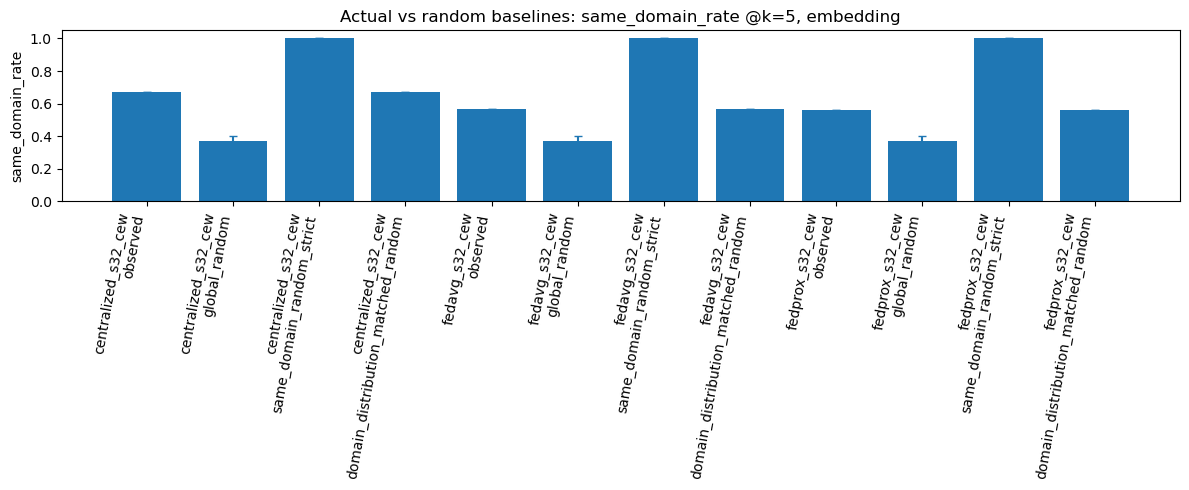

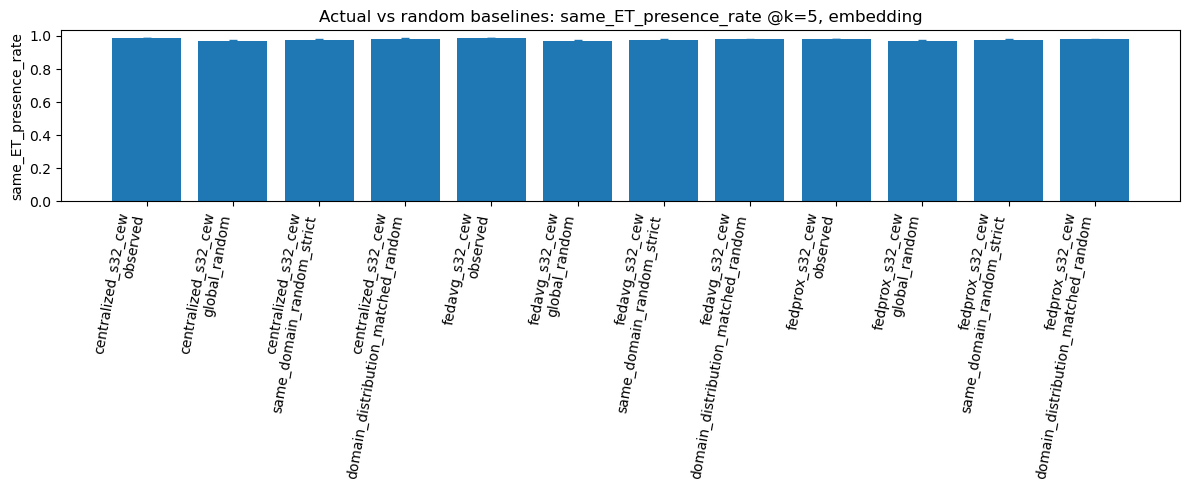

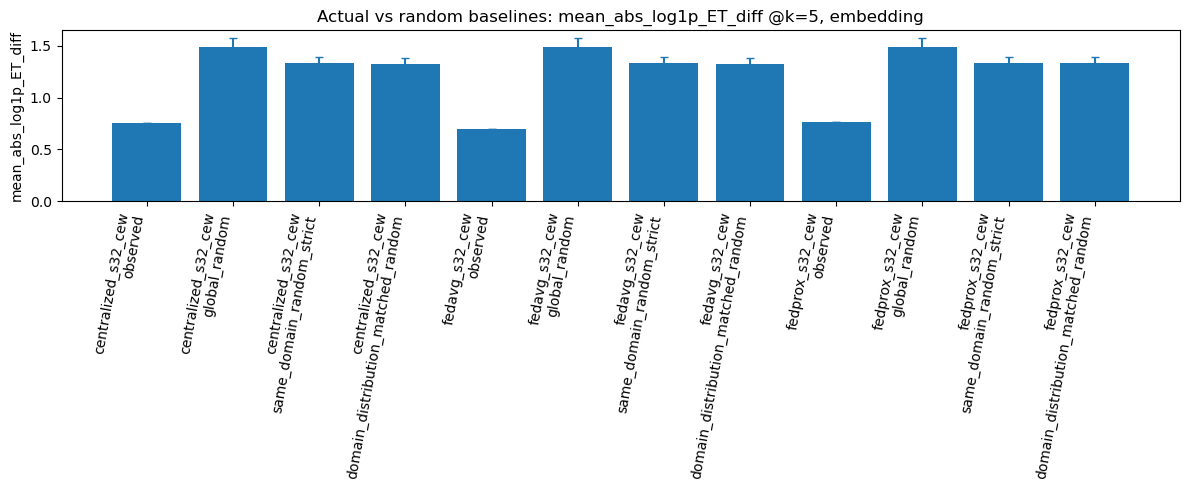

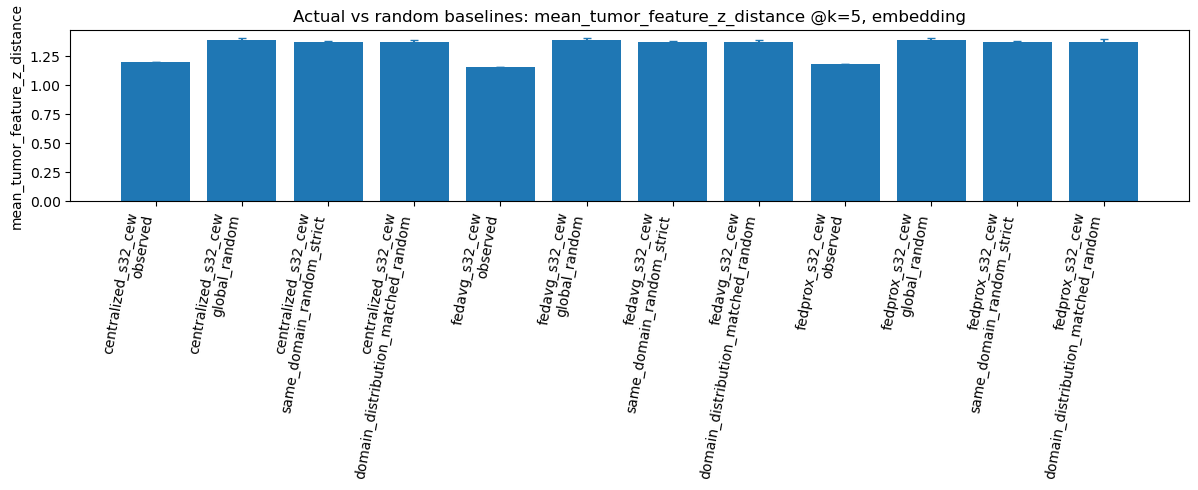

### Figure paths

,metric,png,pdf
0,same_domain_rate,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...
1,same_ET_presence_rate,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...
2,mean_abs_log1p_ET_diff,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...
3,mean_tumor_feature_z_distance,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/14_figure_paths.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/14_figure_paths.csv')

In [21]:


def plot_actual_vs_baselines(metric, retrieval_space=None, k=None):
    retrieval_space = retrieval_space or primary_space
    k = int(k or primary_k)

    df = actual_vs_baseline_df[
        (actual_vs_baseline_df["retrieval_space"] == retrieval_space)
        & (actual_vs_baseline_df["k"].astype(int) == k)
        & (actual_vs_baseline_df["metric"] == metric)
    ].copy()

    if len(df) == 0:
        print("No data for", metric, retrieval_space, k)
        return None, None

    exp_keys = sorted(df["experiment_key"].unique())
    rows = []
    for exp_key in exp_keys:
        g = df[df["experiment_key"] == exp_key]
        rows.append({
            "label": f"{exp_key}\nobserved",
            "value": g["observed_value"].iloc[0],
            "low": np.nan,
            "high": np.nan
        })
        for b in CFG["baseline_types"]:
            br = g[g["baseline_type"] == b]
            if len(br) == 0:
                continue
            rows.append({
                "label": f"{exp_key}\n{b}",
                "value": br["baseline_mean"].iloc[0],
                "low": br["baseline_ci95_low"].iloc[0],
                "high": br["baseline_ci95_high"].iloc[0],
            })

    pdf = pd.DataFrame(rows)
    x = np.arange(len(pdf))
    y = pdf["value"].to_numpy(dtype=float)

    yerr_low, yerr_high = [], []
    for _, r in pdf.iterrows():
        if pd.isna(r["low"]) or pd.isna(r["high"]):
            yerr_low.append(0.0)
            yerr_high.append(0.0)
        else:
            yerr_low.append(max(r["value"] - r["low"], 0.0))
            yerr_high.append(max(r["high"] - r["value"], 0.0))

    plt.figure(figsize=(max(12, len(pdf) * 0.55), 5))
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=np.vstack([yerr_low, yerr_high]), fmt="none", capsize=3)
    plt.xticks(x, pdf["label"], rotation=80, ha="right")
    plt.ylabel(metric)
    plt.title(f"Actual vs random baselines: {metric} @k={k}, {retrieval_space}")
    plt.tight_layout()

    png = FIG_DIR / f"actual_vs_baselines_{metric}_{retrieval_space}_k{k}.png"
    pdf_path = FIG_DIR / f"actual_vs_baselines_{metric}_{retrieval_space}_k{k}.pdf"
    plt.savefig(png, dpi=200, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png, pdf_path

fig_rows = []
for metric in [
    "same_domain_rate",
    "same_ET_presence_rate",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance"
]:
    png, pdf_path = plot_actual_vs_baselines(metric, primary_space, primary_k)
    if png is not None:
        fig_rows.append({"metric": metric, "png": str(png), "pdf": str(pdf_path)})

figure_paths_df = pd.DataFrame(fig_rows)
safe_display("Figure paths", figure_paths_df)
save_dataframe(figure_paths_df, "14_figure_paths")

## Baseline report

In [22]:


distance_metrics = [
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]

metric_labels = {
    "mean_abs_log1p_WT_diff": "WT volume diff",
    "mean_abs_log1p_TC_diff": "TC volume diff",
    "mean_abs_log1p_ET_diff": "ET volume diff",
    "mean_tumor_feature_z_distance": "Tumor z-distance",
}


# Domain-matched control summary
verdict_report_df = verdict_df[
    [
        "experiment_key",
        "verdict",
        "n_distance_metrics_better_than_domain_matched_random",
        "n_distance_metrics_available",
        "n_consistency_metrics_better_than_domain_matched_random",
        "n_consistency_metrics_available",
    ]
].copy()

verdict_report_df = verdict_report_df.rename(
    columns={
        "experiment_key": "Experiment",
        "verdict": "Verdict",
        "n_distance_metrics_better_than_domain_matched_random": "Distance metrics better",
        "n_distance_metrics_available": "Distance metrics total",
        "n_consistency_metrics_better_than_domain_matched_random": "Consistency metrics better",
        "n_consistency_metrics_available": "Consistency metrics total",
    }
)


# Predicted-ROI localization summary
center_report_df = center_overall_df.copy()

center_keep = [
    col
    for col in [
        "experiment_key",
        "no_pred_wt_rate",
        "mean_pred_to_gt_wt_center_distance",
        "median_pred_to_gt_wt_center_distance",
    ]
    if col in center_report_df.columns
]

center_report_df = center_report_df[center_keep].copy()

center_report_df = center_report_df.rename(
    columns={
        "experiment_key": "Experiment",
        "no_pred_wt_rate": "No-WT fallback rate",
        "mean_pred_to_gt_wt_center_distance": "Mean center distance",
        "median_pred_to_gt_wt_center_distance": "Median center distance",
    }
)

for col in center_report_df.columns:
    if col != "Experiment":
        center_report_df[col] = (
            pd.to_numeric(center_report_df[col], errors="coerce")
            .round(4)
        )


# Primary embedding comparison
metric_order = [
    "same_domain_rate",
    "same_ET_presence_rate",
    *distance_metrics,
]

primary_report_df = primary_compact_df[
    primary_compact_df["metric"].isin(metric_order)
].copy()

primary_report_df = primary_report_df[
    [
        "experiment_key",
        "metric",
        "observed",
        "global_random_mean",
        "domain_distribution_matched_random_mean",
        "domain_distribution_matched_random_flag",
    ]
].rename(
    columns={
        "experiment_key": "Experiment",
        "metric": "Metric",
        "observed": "Observed",
        "global_random_mean": "Global random",
        "domain_distribution_matched_random_mean": "Domain-matched random",
        "domain_distribution_matched_random_flag": "DM flag",
    }
)

for col in [
    "Observed",
    "Global random",
    "Domain-matched random",
]:
    primary_report_df[col] = (
        pd.to_numeric(primary_report_df[col], errors="coerce")
        .round(4)
    )


# Best observed model for each primary distance metric
best_rows = []

for metric in distance_metrics:
    rows = primary_compact_df[
        primary_compact_df["metric"] == metric
    ].copy()

    rows["observed"] = pd.to_numeric(
        rows["observed"],
        errors="coerce",
    )

    rows = rows.dropna(subset=["observed"])

    if rows.empty:
        continue

    best = rows.loc[rows["observed"].idxmin()]

    best_rows.append(
        {
            "Metric": metric_labels[metric],
            "Experiment": best["experiment_key"],
            "Observed": float(best["observed"]),
        }
    )

best_model_df = pd.DataFrame(best_rows)

if not best_model_df.empty:
    best_model_df["Observed"] = best_model_df["Observed"].round(4)


# Overall domain-matched result
expected_distance_metrics = len(distance_metrics)

all_distance_metrics_available = bool(
    not verdict_df.empty
    and (
        verdict_df["n_distance_metrics_available"]
        == expected_distance_metrics
    ).all()
)

all_distance_metrics_better = bool(
    all_distance_metrics_available
    and (
        verdict_df[
            "n_distance_metrics_better_than_domain_matched_random"
        ]
        == expected_distance_metrics
    ).all()
)

if all_distance_metrics_better:
    result_note = (
        "All enabled experiments outperform the "
        "domain-distribution-matched random control on all four "
        "primary phenotype-distance metrics."
    )
elif not all_distance_metrics_available:
    result_note = (
        "At least one experiment is missing one or more primary "
        "phenotype-distance comparisons."
    )
else:
    result_note = (
        "At least one experiment-metric comparison does not outperform "
        "the domain-distribution-matched random control."
    )


report_parts = [
    "# 08d Predicted-mask ROI Baseline Report",
    "",
    "## Evaluation setup",
    "",
    f"- Source 08c directory: `{CFG['source_08c_dir']}`",
    f"- Patients: `{len(eval_df)}`",
    f"- Split: `{split_values}`",
    "- ROI source: predicted WT center",
    "- GT ROI fallback: disabled",
    "- Primary retrieval space: `embedding`",
    f"- k: `{primary_k}`",
    f"- Random repeats: `{CFG['n_random_repeats']}`",
    "",
    "## Baselines",
    "",
    "- `global_random`: random non-self neighbors from the full test set.",
    "- `same_domain_random_strict`: random neighbors restricted to the query domain.",
    (
        "- `domain_distribution_matched_random`: random neighbors sampled "
        "to reproduce the retrieved-domain composition of the learned result."
    ),
    "",
    "## Predicted-ROI localization",
    "",
    center_report_df.to_markdown(index=False),
    "",
    "## Domain-matched control summary",
    "",
    verdict_report_df.to_markdown(index=False),
    "",
    f"## Primary embedding comparison at k={primary_k}",
    "",
    primary_report_df.to_markdown(index=False),
    "",
    "## Best observed phenotype distances",
    "",
    best_model_df.to_markdown(index=False),
    "",
    "## Result summary",
    "",
    result_note,
    "",
    "## Method notes",
    "",
    (
        "- Lower WT, TC, ET volume differences and tumor z-distance "
        "indicate closer tumor-phenotype similarity."
    ),
    (
        "- The domain-distribution-matched control preserves retrieved-domain "
        "composition and therefore controls for domain composition in the "
        "primary phenotype-distance comparison."
    ),
    (
        "- Same-domain rate is reported as a domain-clustering diagnostic, "
        "not as a retrieval-quality metric."
    ),
    (
        "- Ground-truth tumor features are used to score retrieved-neighbor "
        "phenotype similarity; they are not used for predicted-ROI localization "
        "or primary embedding ranking."
    ),
    "",
    "## Outputs",
    "",
    f"- Primary comparison: `{TABLE_DIR / '09_primary_baseline_comparison_embedding_k5.csv'}`",
    f"- Domain-matched control: `{TABLE_DIR / '10_domain_distribution_matched_control_embedding_k5.csv'}`",
    f"- Verdict table: `{TABLE_DIR / '11_baseline_comparison_summary.csv'}`",
    f"- Tables: `{TABLE_DIR}`",
    f"- Reports: `{REPORT_DIR}`",
    "",
]


report_text = "\n".join(report_parts)

report_path = (
    REPORT_DIR
    / "08d_predicted_roi_random_domain_matched_baseline_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

display(Markdown(report_text))
print("saved report:", report_path)

# 08d Predicted-mask ROI Baseline Report

## Evaluation setup

- Source 08c directory: `docs/08c_predicted_mask_roi_embedding_retrieval_test`
- Patients: `211`
- Split: `['test']`
- ROI source: predicted WT center
- GT ROI fallback: disabled
- Primary retrieval space: `embedding`
- k: `5`
- Random repeats: `1000`

## Baselines

- `global_random`: random non-self neighbors from the full test set.
- `same_domain_random_strict`: random neighbors restricted to the query domain.
- `domain_distribution_matched_random`: random neighbors sampled to reproduce the retrieved-domain composition of the learned result.

## Predicted-ROI localization

| Experiment          |   No-WT fallback rate |   Mean center distance |   Median center distance |
|:--------------------|----------------------:|-----------------------:|-------------------------:|
| centralized_s32_cew |                     0 |                 1.9365 |                   1.4142 |
| fedavg_s32_cew      |                     0 |                 2.4682 |                   1.4142 |
| fedprox_s32_cew     |                     0 |                 2.5301 |                   1.4142 |

## Domain-matched control summary

| Experiment          | Verdict                                                          |   Distance metrics better |   Distance metrics total |   Consistency metrics better |   Consistency metrics total |
|:--------------------|:-----------------------------------------------------------------|--------------------------:|-------------------------:|-----------------------------:|----------------------------:|
| centralized_s32_cew | stronger_than_domain_matched_random_on_multiple_distance_metrics |                         4 |                        4 |                            0 |                           1 |
| fedavg_s32_cew      | stronger_than_domain_matched_random_on_multiple_distance_metrics |                         4 |                        4 |                            1 |                           1 |
| fedprox_s32_cew     | stronger_than_domain_matched_random_on_multiple_distance_metrics |                         4 |                        4 |                            0 |                           1 |

## Primary embedding comparison at k=5

| Experiment          | Metric                        |   Observed |   Global random |   Domain-matched random | DM flag                              |
|:--------------------|:------------------------------|-----------:|----------------:|------------------------:|:-------------------------------------|
| centralized_s32_cew | mean_abs_log1p_ET_diff        |     0.7549 |          1.4898 |                  1.3253 | better_than_random                   |
| centralized_s32_cew | mean_abs_log1p_TC_diff        |     0.633  |          1.2715 |                  1.2655 | better_than_random                   |
| centralized_s32_cew | mean_abs_log1p_WT_diff        |     0.5715 |          0.8624 |                  0.8543 | better_than_random                   |
| centralized_s32_cew | mean_tumor_feature_z_distance |     1.2    |          1.3879 |                  1.374  | better_than_random                   |
| centralized_s32_cew | same_ET_presence_rate         |     0.9848 |          0.9717 |                  0.9804 | within_random_interval               |
| centralized_s32_cew | same_domain_rate              |     0.6711 |          0.3731 |                  0.6711 | domain_leakage_or_composition_metric |
| fedavg_s32_cew      | mean_abs_log1p_ET_diff        |     0.6925 |          1.4898 |                  1.3238 | better_than_random                   |
| fedavg_s32_cew      | mean_abs_log1p_TC_diff        |     0.587  |          1.2715 |                  1.2649 | better_than_random                   |
| fedavg_s32_cew      | mean_abs_log1p_WT_diff        |     0.4693 |          0.8624 |                  0.8517 | better_than_random                   |
| fedavg_s32_cew      | mean_tumor_feature_z_distance |     1.1561 |          1.3879 |                  1.375  | better_than_random                   |
| fedavg_s32_cew      | same_ET_presence_rate         |     0.9848 |          0.9717 |                  0.9787 | better_than_random                   |
| fedavg_s32_cew      | same_domain_rate              |     0.5678 |          0.3731 |                  0.5678 | domain_leakage_or_composition_metric |
| fedprox_s32_cew     | mean_abs_log1p_ET_diff        |     0.7608 |          1.4898 |                  1.3372 | better_than_random                   |
| fedprox_s32_cew     | mean_abs_log1p_TC_diff        |     0.5998 |          1.2715 |                  1.2615 | better_than_random                   |
| fedprox_s32_cew     | mean_abs_log1p_WT_diff        |     0.4996 |          0.8624 |                  0.8529 | better_than_random                   |
| fedprox_s32_cew     | mean_tumor_feature_z_distance |     1.1799 |          1.3879 |                  1.3778 | better_than_random                   |
| fedprox_s32_cew     | same_ET_presence_rate         |     0.981  |          0.9717 |                  0.9796 | within_random_interval               |
| fedprox_s32_cew     | same_domain_rate              |     0.5611 |          0.3731 |                  0.5611 | domain_leakage_or_composition_metric |

## Best observed phenotype distances

| Metric           | Experiment     |   Observed |
|:-----------------|:---------------|-----------:|
| WT volume diff   | fedavg_s32_cew |     0.4693 |
| TC volume diff   | fedavg_s32_cew |     0.587  |
| ET volume diff   | fedavg_s32_cew |     0.6925 |
| Tumor z-distance | fedavg_s32_cew |     1.1561 |

## Result summary

All enabled experiments outperform the domain-distribution-matched random control on all four primary phenotype-distance metrics.

## Method notes

- Lower WT, TC, ET volume differences and tumor z-distance indicate closer tumor-phenotype similarity.
- The domain-distribution-matched control preserves retrieved-domain composition and therefore controls for domain composition in the primary phenotype-distance comparison.
- Same-domain rate is reported as a domain-clustering diagnostic, not as a retrieval-quality metric.
- Ground-truth tumor features are used to score retrieved-neighbor phenotype similarity; they are not used for predicted-ROI localization or primary embedding ranking.

## Outputs

- Primary comparison: `/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/09_primary_baseline_comparison_embedding_k5.csv`
- Domain-matched control: `/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/10_domain_distribution_matched_control_embedding_k5.csv`
- Verdict table: `/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/11_baseline_comparison_summary.csv`
- Tables: `/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables`
- Reports: `/home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/reports`


saved report: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/reports/08d_predicted_roi_random_domain_matched_baseline_report.md


## Output validation

In [23]:


experiment_keys = [
    str(exp)
    for exp in experiments
]

def has_complete_metric_grid(df, experiment_keys, metrics):
    required_cols = {"experiment_key", "metric"}

    if df.empty or not required_cols.issubset(df.columns):
        return False

    expected = {
        (str(exp_key), str(metric))
        for exp_key in experiment_keys
        for metric in metrics
    }

    actual = set(
        zip(
            df["experiment_key"].astype(str),
            df["metric"].astype(str),
        )
    )

    return expected.issubset(actual)


primary_table_complete = has_complete_metric_grid(
    primary_compact_df,
    experiment_keys,
    primary_metrics,
)

domain_control_complete = has_complete_metric_grid(
    domain_matched_control_df,
    experiment_keys,
    domain_control_metrics,
)


primary_required_cols = [
    "experiment_key",
    "metric",
    "observed",
    "domain_distribution_matched_random_flag",
]

primary_no_nan = bool(
    set(primary_required_cols).issubset(primary_compact_df.columns)
    and not primary_compact_df[
        primary_required_cols
    ].isna().any().any()
)


verdict_complete = bool(
    not verdict_df.empty
    and len(verdict_df) == len(experiment_keys)
    and (
        verdict_df["n_distance_metrics_available"]
        == len(distance_metrics)
    ).all()
)


checks = {
    "source_artifacts_available": bool(
        artifact_df.loc[
            artifact_df["required"],
            "exists",
        ].all()
    ),
    "source_08c_complete": bool(source_08c_ready),
    "integrity_passed": bool(
        integrity_df["passed"].all()
    ),
    "random_baseline_runs_available": (
        not baseline_run_metrics_df.empty
    ),
    "baseline_summary_available": (
        not baseline_summary_df.empty
    ),
    "observed_vs_baseline_available": (
        not actual_vs_baseline_df.empty
    ),
    "primary_table_available": (
        not primary_compact_df.empty
    ),
    "primary_table_complete": primary_table_complete,
    "primary_table_valid": primary_no_nan,
    "domain_matched_control_available": (
        not domain_matched_control_df.empty
    ),
    "domain_matched_control_complete": (
        domain_control_complete
    ),
    "verdict_available": (
        not verdict_df.empty
    ),
    "verdict_complete": verdict_complete,
    "report_saved": report_path.exists(),
}

checks["complete"] = all(checks.values())


checks_df = pd.DataFrame([checks])

safe_display(
    "08d output checks",
    checks_df,
)

save_dataframe(
    checks_df,
    "15_output_checks",
)


run_manifest = {
    "cfg": CFG,
    "project_root": str(PROJECT_ROOT),
    "output_dir": str(OUT_DIR),
    "source_08c_paths": {
        key: str(value)
        for key, value in paths.items()
    },
    "optional_source_08c_paths": {
        key: str(value) if value is not None else None
        for key, value in optional_paths.items()
    },
    "checks": checks,
}

run_manifest_path = (
    LOG_DIR
    / "08d_run_manifest.json"
)

run_manifest_path.write_text(
    json.dumps(
        run_manifest,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

print("saved run manifest:", run_manifest_path)


if checks["complete"]:
    display(
        Markdown(
            "**PASS:** all expected 08d outputs are available."
        )
    )
else:
    failed = [
        name
        for name, passed in checks.items()
        if name != "complete" and not passed
    ]

    display(
        Markdown(
            "**FAIL:** missing or invalid checks: "
            + ", ".join(f"`{name}`" for name in failed)
        )
    )

### 08d output checks

,source_artifacts_available,source_08c_complete,integrity_passed,random_baseline_runs_available,baseline_summary_available,observed_vs_baseline_available,primary_table_available,primary_table_complete,primary_table_valid,domain_matched_control_available,domain_matched_control_complete,verdict_available,verdict_complete,report_saved,complete
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/15_output_checks.csv
saved run manifest: /home/mandrakedrink/projects/research_ts_bs/docs/08d_predicted_roi_random_and_domain_matched_baselines_test/logs/08d_run_manifest.json


**PASS:** all expected 08d outputs are available.